![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [4]:
pd.set_option('display.max_columns', None)

In [5]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [6]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [7]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [8]:
bikes.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000


In [9]:
bikes.groupby('season').total.describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [10]:
bikes.groupby('hour').total.describe()

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


#### **Variable hour**
Son alrededor de 450 observaciones por hora. Se denotan dos picos, una a las 8 y la otra a las 17 horas. Se infiere que las personas utilizan el sistema para ir al trabajo por la mañana y para regresar a sus casas en la tarde.

El pico de las 8am es el segundo valor medio más alto del día. La mediana (392) supera a la media, lo que indica que más del 50% de los días registra valores por encima del promedio general, sugiriendo consistencia en este pico. Para el pico de las 5pm es el máximo absoluto del día. La cercanía entre media y mediana (diferencia de alrededor de 12 unidades) refleja una distribución relativamente simétrica, es decir, el comportamiento de alta demanda a esta hora es estable y predecible.

La hora 4 AM registra la media más baja (6.4) y un máximo de apenas 28, lo que confirma que prácticamente no hay actividad en ese rango. Nótese que a las 3 AM la desviación estándar (12.7) supera a la mediana (6), lo que indica una alta variabilidad relativa: la mayoría de los días hay muy poca demanda, pero ocasionalmente se registran valores atípicamente altos (posiblemente fines de semana o eventos nocturnos).

#### **Variable Season** 1:winter, 2:spring, 3:summer, 4:fall

**1:winter:** La media (116.3) casi duplica a la mediana (78), lo que señala una distribución fuertemente sesgada a la derecha: la mayoría de los registros se concentran en valores bajos, pero hay observaciones extremas que jalan la media hacia arriba. El P25 de apenas 24 confirma que el 25% de los registros más bajos son muy reducidos. Las condiciones climáticas adversas explican este comportamiento. Por lo tanto, hay una demanda baja y asimetrica.

**2:spring:** Respecto al invierno, la media casi se duplica (alrededor de 85%). El rango intercuartílico (P25=49, P75=321) es amplio, lo que sugiere alta variabilidad: hay días de clima favorable con demanda alta y días aún fríos con demanda baja. La transición estacional se refleja en esta dispersión. Hay una recuperación significativa.

**3:summer:** Es la temporada con la mayor media (234.4), mayor mediana (195) y mayor máximo (977). La diferencia media-mediana es de 39 unidades, proporcionalmente menor que en invierno, lo que indica una distribución más equilibrada. El buen clima estabiliza y eleva la demanda de forma consistente. Es donde está el pico de demanda anual.

**4:fall:** Ligeramente por debajo del verano, pero sustancialmente por encima del invierno. El máximo (948) es el segundo más alto, lo que sugiere que en días cálidos de otoño se pueden alcanzar niveles de demanda similares al verano. En esta temporada hay un descenso moderado

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

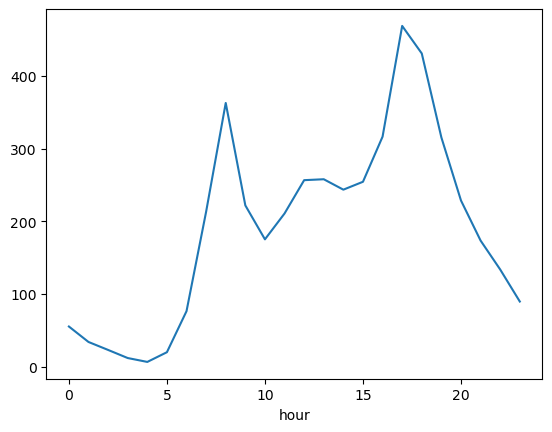

In [11]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

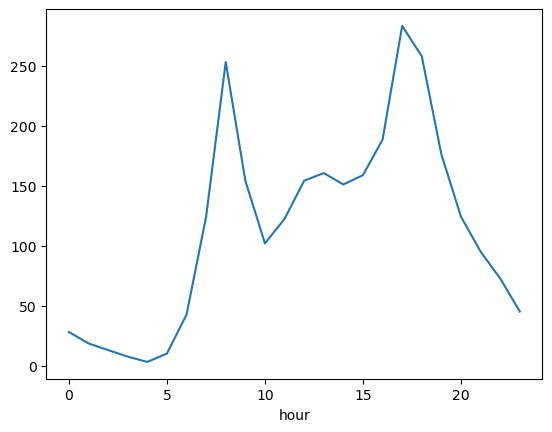

In [12]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour')['total'].mean().plot()

<Axes: xlabel='hour'>

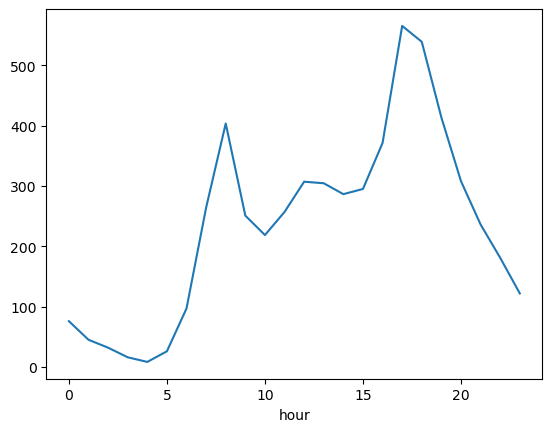

In [13]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour')['total'].mean().plot()

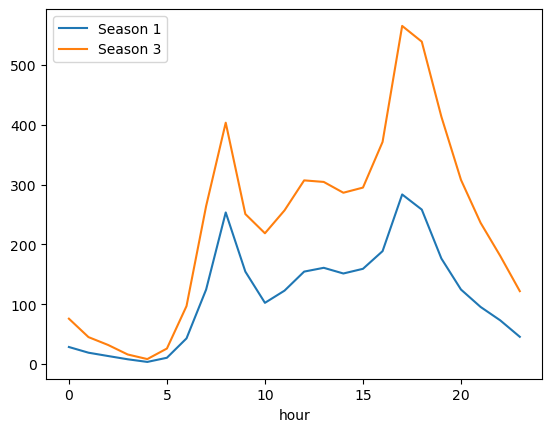

In [14]:
for season in [1, 3]:
    bikes[bikes['season'] == season].groupby('hour')['total'].mean().plot(label=f'Season {season}')

plt.legend()
plt.show()

Se puede visualizar que tanto en invierno como en verano manejan el mismo patrón en el trasncurso de las horas. Ambas líneas casi se tocan cerca de cero entre 0 a 5am, hay un primer pico a las 8am y un segungo pico a las 17; en consecuencia, hay un patrón binomial.
Pero hay una clara disminución en el promedio de la cantidad de alquileres en la temporada de invierno en relación al verano. El frío reduce el uso de bicicletas de forma consistente durante todo el día.

Las dos curvas tienen exactamente la misma forma bimodal con picos en 8 AM y 5 PM. Esto confirma que el patrón es estructural (independiente de la temporada), pero la intensidad sí depende del clima.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [15]:
df_encoding = pd.get_dummies(bikes, columns=['season'], drop_first=True)
# Conviertiendo las columnas de temporada a enteros (0 y 1)
season_cols = [col for col in df_encoding.columns if col.startswith('season_')]
df_encoding[season_cols] = df_encoding[season_cols].astype(int)

In [16]:
df_encoding.head()

,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour,season_2,season_3,season_4
datetime,,,,,,,,,,,,,,
2011-01-01 00:00:00,0,0,1,9.84,14.395,81,0.0,3,13,16,0,0,0,0
2011-01-01 01:00:00,0,0,1,9.02,13.635,80,0.0,8,32,40,1,0,0,0
2011-01-01 02:00:00,0,0,1,9.02,13.635,80,0.0,5,27,32,2,0,0,0
2011-01-01 03:00:00,0,0,1,9.84,14.395,75,0.0,3,10,13,3,0,0,0
2011-01-01 04:00:00,0,0,1,9.84,14.395,75,0.0,0,1,1,4,0,0,0


In [17]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  total       10886 non-null  int64  
 11  hour        10886 non-null  int32  
dtypes: float64(3), int32(1), int64(8)
memory usage: 1.0 MB


In [18]:
# Celda 3
X = df_encoding[['season_2','season_3','season_4', 'hour']]
y = df_encoding['total']

In [19]:
X.head()

,season_2,season_3,season_4,hour
datetime,,,,
2011-01-01 00:00:00,0,0,0,0
2011-01-01 01:00:00,0,0,0,1
2011-01-01 02:00:00,0,0,0,2
2011-01-01 03:00:00,0,0,0,3
2011-01-01 04:00:00,0,0,0,4


In [20]:
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.33, random_state=0)

In [21]:
# Celda 3.1 - Modelo Regresión Lineal
model_lr = LinearRegression()
model_lr.fit(XTrain, yTrain)

yTrain_pred = model_lr.predict(XTrain)
yTest_pred = model_lr.predict(XTest)

print("Coeficientes del modelo:")
print(f"Intercepto: {model_lr.intercept_:.4f}")
for i, coef in enumerate(model_lr.coef_):
    print(f"Coeficiente {i+1}: {coef:.4f}")

print(f"\nTrain R2 Score: {r2_score(yTrain, yTrain_pred):.4f}")
print(f"Test R2 Score: {r2_score(yTest, yTest_pred):.4f}")
print(f"\nTrain RMSE: {np.sqrt(mean_squared_error(yTrain, yTrain_pred)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(yTest, yTest_pred)):.4f}")

Coeficientes del modelo:
Intercepto: -9.5631
Coeficiente 1: 100.9078
Coeficiente 2: 119.0187
Coeficiente 3: 87.2474
Coeficiente 4: 10.6287

Train R2 Score: 0.2270
Test R2 Score: 0.2152

Train RMSE: 159.3930
Test RMSE: 160.1388


| Variable | Coeficiente | Interpretación |
|----------|-------------|----------------|
| season_2 (Primavera) | +100.91 | Primavera genera 101 alquileres más que invierno |
| season_3 (Verano) | +119.02 | Verano genera 119 alquileres más que invierno |
| season_4 (Otoño) | +87.25 | Otoño genera 87 alquileres más que invierno |


Verano supera a invierno en 119 unidades, y es la temporada de mayor efecto positivo, consistente con todo el análisis descriptivo previo. La jerarquía es Verano > Primavera > Otoño > Invierno.

Coeficiente de hour (+10.63) Por cada hora adicional del día, el modelo predice 10.6 alquileres más. Esto implica que el modelo asume una relación lineal y creciente entre la hora y la demanda, es decir, a las 23h predice más que a las 0h de forma constante. Esto es claramente incorrecto dado el patrón bimodal que observamos.

**Limitaciones**
* *hour* tratada como variable numérica continua Es la limitación más grave. El modelo asume que la demanda crece linealmente con la hora (+10.63 por hora), pero los datos muestran un patrón bimodal con picos a las 8 AM y 17 PM y un valle profundo en la madrugada. Una línea recta no puede capturar esa curva. La solución sería tratar hour también como dummy o usar transformaciones no lineales.

* R² muy bajo (0.22) El modelo solo explica el 22% de la varianza de la variable objetivo. Para un modelo predictivo esto es inaceptable. En producción generaría predicciones muy poco confiables.

* RMSE alto (160) El error promedio de predicción es de 160 alquileres. Considerando que la media general del dataset ronda los 190, el error es casi tan grande como el valor típico que se quiere predecir.

* No captura interacciones el modelo no considera que el efecto de la hora es distinto según la temporada. En verano el pico de las 17h es mucho más pronunciado que en invierno, pero el modelo aplica el mismo coeficiente de hour para todas las temporadas.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [22]:
# Celda 4
X = bikes[['season', 'hour']]
y = bikes['total']

In [23]:
X.columns

Index(['season', 'hour'], dtype='object')

In [24]:
def mse_impurity(y):
    # Varianza del nodo. Si está vacío o tiene un solo valor → 0
    if len(y) <= 1:
        return 0
    return np.var(y)

In [25]:
def mse_gain(X_col, y, split):
    
    # Calcula la reducción de varianza al dividir X_col en el umbral 'split'.
    # - Izquierda: observaciones con valor < split
    # - Derecha:   observaciones con valor >= split
    
    mask_izq = X_col < split
    y_izq = y[mask_izq]
    y_der = y[~mask_izq]
    
    n       = len(y)
    n_izq   = len(y_izq)
    n_der   = len(y_der)
    
    # Ganancia = varianza actual - varianza ponderada de los hijos
    ganancia = (mse_impurity(y)
                - (n_izq / n) * mse_impurity(y_izq)
                - (n_der / n) * mse_impurity(y_der))
    
    return ganancia

In [26]:
def mejor_corte(X, y, num_pct=10):
    
    # Itera sobre todas las variables y percentiles para encontrar
    # la variable j y el umbral split que maximizan la ganancia.
    
    mejor = {'variable': None, 'umbral': None, 'ganancia': -np.inf}
    
    for j in range(X.shape[1]):          # Para cada variable
        col = X.iloc[:, j]
        
        # Generar posibles umbrales como percentiles de la variable
        percentiles = np.arange(0, 100, 100.0 / (num_pct + 1))
        umbrales = np.unique(np.percentile(col, percentiles))[1:]
        
        for umbral in umbrales:          # Para cada umbral
            ganancia = mse_gain(col, y, umbral)
            
            if ganancia > mejor['ganancia']:
                mejor = {
                    'variable': j,
                    'umbral': umbral,
                    'ganancia': ganancia,
                    'nombre': X.columns[j]
                }
    
    return mejor

In [27]:
def crecer_arbol(X, y, nivel=0, min_ganancia=0.001, max_profundidad=4, num_pct=10):
    
    # Construye el árbol recursivamente.
    # Cada nodo es un diccionario con:
    #   - y_pred:      predicción (promedio de y en ese nodo)
    #   - n:           número de observaciones
    #   - nivel:       profundidad del nodo
    #   - split:       [variable, umbral] usados para dividir (None si es hoja)
    #   - izquierda:   subárbol izquierdo (X_col < umbral)
    #   - derecha:     subárbol derecho   (X_col >= umbral)
    
    nodo = {
        'y_pred': np.mean(y),          # Predicción: promedio del nodo
        'n':      len(y),
        'nivel':  nivel,
        'split':  None                  # None = nodo hoja
    }
    
    # Criterios de parada 
    if len(y) <= 1:
        return nodo
    
    if max_profundidad is not None and nivel >= max_profundidad:
        return nodo
    
    # Encontrar el mejor corte 
    corte = mejor_corte(X, y, num_pct)
    
    if corte['ganancia'] < min_ganancia:
        return nodo                      # No hay ganancia suficiente → hoja
    
    # Dividir los datos
    j      = corte['variable']
    umbral = corte['umbral']
    mask   = X.iloc[:, j] < umbral
    
    X_izq, y_izq = X[mask],  y[mask]
    X_der, y_der = X[~mask], y[~mask]
    
    if len(y_izq) == 0 or len(y_der) == 0:
        return nodo                      # División vacía → hoja
    
    # Guardar la división y continuar recursivamente 
    nodo['split']     = corte
    nodo['izquierda'] = crecer_arbol(X_izq, y_izq, nivel + 1, min_ganancia, max_profundidad, num_pct)
    nodo['derecha']   = crecer_arbol(X_der, y_der, nivel + 1, min_ganancia, max_profundidad, num_pct)
    
    return nodo


In [28]:
def predecir_uno(x, nodo):
    # Predice para una sola observación recorriendo el árbol.
    if nodo['split'] is None:            # Nodo hoja → devuelve promedio
        return nodo['y_pred']
    
    j      = nodo['split']['variable']
    umbral = nodo['split']['umbral']
    
    if x.iloc[j] < umbral:
        return predecir_uno(x, nodo['izquierda'])
    else:
        return predecir_uno(x, nodo['derecha'])

def predecir(X, arbol):
    """Predice para todo el DataFrame."""
    return np.array([predecir_uno(X.iloc[i], arbol) for i in range(len(X))])

In [29]:
def imprimir_arbol(nodo, indent=""):
    # Imprime la estructura del árbol en consola.
    if nodo['split'] is None:
        print(f"{indent}[HOJA] pred={nodo['y_pred']:.1f}  n={nodo['n']}")
        return
    
    nombre  = nodo['split']['nombre']
    umbral  = nodo['split']['umbral']
    ganancia = nodo['split']['ganancia']
    
    print(f"{indent}[nivel {nodo['nivel']}] {nombre} < {umbral:.2f}  "
          f"(ganancia={ganancia:.2f}, n={nodo['n']})")
    print(f"{indent}├── Izquierda:")
    imprimir_arbol(nodo['izquierda'], indent + "│   ")
    print(f"{indent}└── Derecha:")
    imprimir_arbol(nodo['derecha'],   indent + "    ")

In [30]:
arbol = crecer_arbol(X, y, max_profundidad=3, min_ganancia=0.001, num_pct=10)

In [31]:
imprimir_arbol(arbol)

[nivel 0] hour < 8.00  (ganancia=9134.41, n=10886)
├── Izquierda:
│   [nivel 1] hour < 7.00  (ganancia=3603.85, n=3594)
│   ├── Izquierda:
│   │   [nivel 2] hour < 6.00  (ganancia=323.40, n=3139)
│   │   ├── Izquierda:
│   │   │   [HOJA] pred=25.2  n=2684
│   │   └── Derecha:
│   │       [HOJA] pred=76.3  n=455
│   └── Derecha:
│       [nivel 2] season < 2.00  (ganancia=2598.55, n=455)
│       ├── Izquierda:
│       │   [HOJA] pred=124.4  n=113
│       └── Derecha:
│           [HOJA] pred=242.4  n=342
└── Derecha:
    [nivel 1] hour < 21.00  (ganancia=3696.46, n=7292)
    ├── Izquierda:
    │   [nivel 2] season < 2.00  (ganancia=4152.06, n=5924)
    │   ├── Izquierda:
    │   │   [HOJA] pred=176.1  n=1478
    │   └── Derecha:
    │       [HOJA] pred=325.0  n=4446
    └── Derecha:
        [nivel 2] season < 2.00  (ganancia=1239.14, n=1368)
        ├── Izquierda:
        │   [HOJA] pred=71.2  n=342
        └── Derecha:
            [HOJA] pred=152.5  n=1026


In [32]:
y_pred = predecir(X, arbol)

rmse = np.sqrt(np.mean((y - y_pred)**2))
r2   = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

print(f"\nRMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


RMSE: 131.8823
R²:   0.4699


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [33]:
# Celda 5
X_Arb = bikes[['season', 'hour']]
y_Arb = bikes['total']

XTrain_A, XTest_A, yTrain_A, yTest_A = train_test_split(X_Arb, y_Arb, test_size=0.33, random_state=0)


In [34]:
max_depth_range = range(1, 21)

In [35]:
rmse_scores = []

for depth in max_depth_range:
    model = DecisionTreeRegressor(max_depth=depth, random_state=1)
    scores = cross_val_score(
        model, XTrain_A, yTrain_A,
        cv=10,
        scoring='neg_root_mean_squared_error'
    )
    rmse_scores.append(-scores.mean())

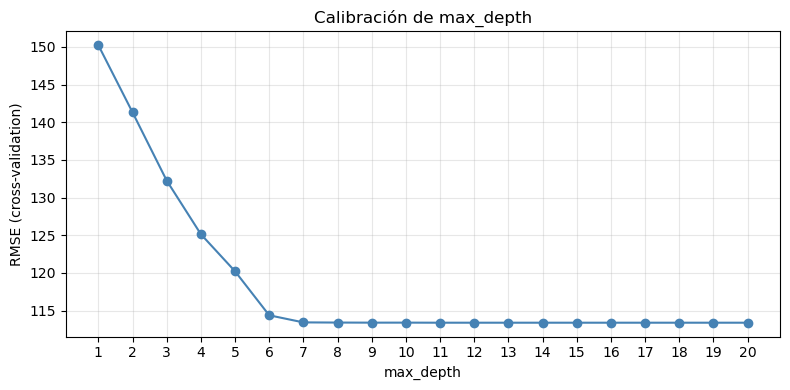

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(max_depth_range, rmse_scores, marker='o', color='steelblue')
plt.xlabel('max_depth')
plt.ylabel('RMSE (cross-validation)')
plt.title('Calibración de max_depth')
plt.xticks(range(1, 21))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
best_depth = max_depth_range[np.argmin(rmse_scores)]
print(f"Mejor max_depth: {best_depth}")

model_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
model_dt.fit(XTrain_A, yTrain_A)

Mejor max_depth: 11


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",11
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf

In [38]:
yTrain_pred_A = model_dt.predict(XTrain_A)
yTest_pred_A  = model_dt.predict(XTest_A)

print("\nÁrbol de decisión sklearn")
print(f"Train R2:   {r2_score(yTrain_A, yTrain_pred_A):.4f}")
print(f"Test  R2:   {r2_score(yTest_A,  yTest_pred_A):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(yTrain_A, yTrain_pred_A)):.4f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(yTest_A,  yTest_pred_A)):.4f}")

# ── Comparación directa con regresión lineal (Punto 3) 
print("\nComparación con Regresión Lineal (Punto 3)")
print(f"{'Modelo':<30} {'Train R2':>10} {'Test R2':>10} {'Test RMSE':>12}")
print("-" * 65)
print(f"{'Regresión Lineal':<30} {r2_score(yTrain, yTrain_pred):>10.4f} {r2_score(yTest, yTest_pred):>10.4f} {np.sqrt(mean_squared_error(yTest, yTest_pred)):>12.4f}")
print(f"{'Árbol sklearn (best_depth)':<30} {r2_score(yTrain_A,yTrain_pred_A):>10.4f} {r2_score(yTest_A,yTest_pred_A):>10.4f} {np.sqrt(mean_squared_error(yTest_A,yTest_pred_A)):>12.4f}")


Árbol de decisión sklearn
Train R2:   0.6190
Test  R2:   0.5901
Train RMSE: 111.8967
Test  RMSE: 115.7376

Comparación con Regresión Lineal (Punto 3)
Modelo                           Train R2    Test R2    Test RMSE
-----------------------------------------------------------------
Regresión Lineal                   0.2270     0.2152     160.1388
Árbol sklearn (best_depth)         0.6190     0.5901     115.7376


El árbol de decisión explica el 59% de la varianza de la variable objetivo en datos no vistos (Test R2 = 0.59), frente al 22% de la regresión lineal. Es una mejora de +37 puntos porcentuales, lo que indica que el árbol captura relaciones que la línea recta simplemente no puede representar como el patrón bimodal de hour y las diferencias entre temporadas.
Pero, un R2 de 0.59 sigue siendo moderado. El 41% restante queda sin explicar, probablemente por variables ausentes del modelo como clima, día de la semana o si es festivo.

El árbol reduce el error promedio de predicción en alrededor de 44 alquileres por hora respecto a la regresión lineal. En términos operativos esto es significativo: si estás planificando cuántas bicicletas disponer, equivocarte en 116 sigue siendo alto, pero es notablemente mejor que equivocarse en 160.

El árbol de decisión es claramente superior a la regresión lineal para este problema. La ganancia viene de su capacidad de hacer cortes no lineales sobre hour; puede representar el valle de madrugada y los dos picos de commuting sin necesidad de especificarlos manualmente.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [39]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,2.0,4.702128,7.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1300.0,259.718000,0.0,843300.0,482257.142857,0.000000,6963.954292,3415.943322,4500.0,4500.0,4500.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.028582,0.028594,0.028578,0.745673,0.168573,0.625376,0.144737,0.053191,0.021277,0.714286,0.285714,0.470000,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,0.0,5.010101,8.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,919.0,250.142857,0.0,843300.0,142712.500000,0.000000,4429.750000,2610.941050,928.0,928.0,928.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.027098,0.025006,0.276713,0.025003,0.646181,0.376439,0.056574,0.030303,0.030303,0.500000,0.500000,0.342778,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,0.0,3.972376,6.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,791.0,205.666667,4800.0,843300.0,229066.666667,2440.825000,3300.698315,2895.516309,1300.0,1300.0,1300.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.033499,0.200063,0.033411,0.033334,0.699693,0.462500,0.535795,0.049724,0.000000,1.000000,0.000000,0.516263,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,0.0,4.467350,7.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1200.0,280.800000,0.0,843300.0,335642.857143,0.000000,4415.722689,2103.971787,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.457963,0.028580,0.456140,0.028627,0.028690,0.425314,0.091016,0.030730,0.023047,0.571429,0.428571,0.436654,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,0.0,5.146893,4.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,935.0,268.250000,1700.0,843300.0,258100.000000,1218.111111,3588.790194,2809.374181,2400.0,8200.0,5300.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.051121,0.050014,0.050167,0.050003,0.798695,0.370238,0.148214,0.039548,0.011299,0.777778,0.222222,0.346429,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [40]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [41]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

##### Calibración árbol de Decisión

In [42]:
max_depth_range = range(2, 25)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for depth in max_depth_range:
    tree = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        min_samples_leaf=8,
        min_samples_split=10,
        random_state=42
    )
    
    cv_acc = cross_val_score(tree, X_train, y_train, cv=cv, scoring='accuracy').mean()
    cv_f1  = cross_val_score(tree, X_train, y_train, cv=cv, scoring='f1_macro').mean()
    
    results.append({
        'depth': depth, 'cv_acc': cv_acc, 'cv_f1': cv_f1,
        'diff': abs(cv_acc - cv_f1)
    })
    print(f"max_depth={depth:>2} | CV Acc={cv_acc:.4f} | CV F1={cv_f1:.4f} | |Acc-F1|={abs(cv_acc-cv_f1):.4f}")

# ── Mejor depth por convergencia Acc ≈ F1 ──
best = min(results, key=lambda x: -x['cv_f1'])  # maximizar F1
print(f"\n→ Mejor max_depth: {best['depth']}")
print(f"  CV Accuracy: {best['cv_acc']:.4f}")
print(f"  CV F1 macro: {best['cv_f1']:.4f}")


max_depth= 2 | CV Acc=0.6264 | CV F1=0.6260 | |Acc-F1|=0.0005
max_depth= 3 | CV Acc=0.6289 | CV F1=0.6252 | |Acc-F1|=0.0037
max_depth= 4 | CV Acc=0.6229 | CV F1=0.6213 | |Acc-F1|=0.0016
max_depth= 5 | CV Acc=0.6122 | CV F1=0.6121 | |Acc-F1|=0.0001
max_depth= 6 | CV Acc=0.6078 | CV F1=0.6071 | |Acc-F1|=0.0007
max_depth= 7 | CV Acc=0.6069 | CV F1=0.6056 | |Acc-F1|=0.0013
max_depth= 8 | CV Acc=0.5929 | CV F1=0.5926 | |Acc-F1|=0.0003
max_depth= 9 | CV Acc=0.5898 | CV F1=0.5896 | |Acc-F1|=0.0002
max_depth=10 | CV Acc=0.5851 | CV F1=0.5846 | |Acc-F1|=0.0005
max_depth=11 | CV Acc=0.5756 | CV F1=0.5750 | |Acc-F1|=0.0006
max_depth=12 | CV Acc=0.5742 | CV F1=0.5740 | |Acc-F1|=0.0003
max_depth=13 | CV Acc=0.5822 | CV F1=0.5821 | |Acc-F1|=0.0002
max_depth=14 | CV Acc=0.5718 | CV F1=0.5714 | |Acc-F1|=0.0004
max_depth=15 | CV Acc=0.5687 | CV F1=0.5685 | |Acc-F1|=0.0002
max_depth=16 | CV Acc=0.5678 | CV F1=0.5676 | |Acc-F1|=0.0002
max_depth=17 | CV Acc=0.5678 | CV F1=0.5676 | |Acc-F1|=0.0001
max_dept

##### Árbol de Decisión

In [43]:
# Celda 6
# Árbol de decisión
tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=best['depth'],
    min_samples_leaf=8,
    min_samples_split=10,
    random_state=42
)

tree_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [44]:
y_pred_ad = tree_model.predict(X_test)

In [45]:
# accuracy = accuracy_score(y_test, y_pred_ad)
# print("Accuracy (Exactitud):", accuracy)

# print("\nMatriz de Confusión:")
# print(confusion_matrix(y_test, y_pred_ad))

# print("\nReporte de Clasificación:")
# ##print(classification_report(y_test, y_pred_ad))
# print(classification_report(y_test, y_pred_ad, target_names=['Exitoso (0)', 'Novedad (1)']))

In [46]:
accuracy_ad = accuracy_score(y_test, y_pred_ad)
print("Accuracy (Exactitud):", accuracy_ad)

# print("\nMatriz de Confusión:")
# print(confusion_matrix(y_test, y_pred_ad))

print(classification_report(y_test, y_pred_ad, target_names=['Exitoso (0)', 'Novedad (1)']))

roc_auc_ad = roc_auc_score(y_test, y_pred_ad)
print(f"ROC-AUC Score: {roc_auc_ad:.4f}")

cv_scores_ad = cross_val_score(tree_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"\nCross-Val ROC-AUC (5-fold): {cv_scores_ad.mean():.4f} ± {cv_scores_ad.std():.4f}")

Accuracy (Exactitud): 0.6453333333333333
              precision    recall  f1-score   support

 Exitoso (0)       0.64      0.65      0.65       744
 Novedad (1)       0.65      0.64      0.64       756

    accuracy                           0.65      1500
   macro avg       0.65      0.65      0.65      1500
weighted avg       0.65      0.65      0.65      1500

ROC-AUC Score: 0.6454

Cross-Val ROC-AUC (5-fold): 0.6525 ± 0.0163


##### Logistica

In [47]:
Modelo_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',   # compensa desbalanceo 10:1
        max_iter=1000,
        solver='lbfgs',
        random_state=42,
        C=1.0                      # regularización L2 por defecto
    ))
])

In [48]:
Modelo_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [49]:
y_pred_lr       = Modelo_lr.predict(X_test)
y_pred_proba_lr = Modelo_lr.predict_proba(X_test)[:, 1]

In [50]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy (Exactitud):", accuracy_lr)

print(classification_report(y_test, y_pred_lr,
                             target_names=['Exitoso (0)', 'Novedad (1)']))

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"ROC-AUC Score: {roc_auc_lr:.4f}")

# Validación cruzada (5-fold estratificado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(Modelo_lr, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"\nCross-Val ROC-AUC (5-fold): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

Accuracy (Exactitud): 0.6386666666666667
              precision    recall  f1-score   support

 Exitoso (0)       0.63      0.67      0.65       744
 Novedad (1)       0.65      0.61      0.63       756

    accuracy                           0.64      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.64      0.64      0.64      1500

ROC-AUC Score: 0.7088

Cross-Val ROC-AUC (5-fold): 0.6921 ± 0.0063


Por Accuracy y F1-Score, el árbol calibrado gana por poco: Accuracy 0.645 vs 0.639, y F1 macro 0.645 vs 0.640. Además, el árbol logra convergencia perfecta entre ambas métricas (diferencia = 0.000), lo que significa que clasifica ambas clases de forma simétrica, no se sesga hacia Exitoso ni hacia Novedad.

En resumen, el árbol calibrado es ligeramente superior en Accuracy y F1, y ambos modelos convergen bien. Pero la logística aporta un AUC más alto.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [51]:
# Celda 7
n_estimators = 300
np.random.seed(123)

n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) 
           for _ in range(n_estimators)]

In [52]:
# Generamos 300 semillas para que cada modelo sea reproducible
seeds = np.random.randint(1, 10000, size=n_estimators)

# print(f"Observaciones en training: {n_samples}")
# print(f"Muestras bootstrap creadas: {len(samples)}")
# print(f"Tamaño de cada muestra: {len(samples[0])}")

In [53]:
modelos = {}

for i in range(n_estimators):
    
    #  Árboles con max_depth = 10 para los primeros 100 modelos
    if i < 100:
        modelos[i] = DecisionTreeClassifier(
            max_depth=10,             # Limitamos profundidad
            random_state=seeds[i]
        )
    
    # Árboles con min_samples_leaf = 15 para los siguientes 100 modelos
    elif i < 200:
        modelos[i] = DecisionTreeClassifier(
            min_samples_leaf=15,      # Mínimo 15 obs por hoja
            random_state=seeds[i]
        )
    
    # Regresiones logísticas con regularización L2 para los últimos 100 modelos
    else:
        modelos[i] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                solver='lbfgs',
                random_state=seeds[i]
            ))
        ])
    
   
    modelos[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

##print("300 modelos entrenados correctamente")


In [54]:
y_pred_df = pd.DataFrame(
    index=X_test.index, 
    columns=list(range(n_estimators))
)

for i in range(n_estimators):
    y_pred_df.iloc[:, i] = modelos[i].predict(X_test)

# # Verificación: shape debe ser (1500, 300)
# print(f"\nDataFrame de predicciones: {y_pred_df.shape}")
# print(f"  Filas = observaciones de test: {y_pred_df.shape[0]}")
# print(f"  Columnas = modelos: {y_pred_df.shape[1]}")


##### Evaluación INDEPENDIENTE de cada grupo

In [55]:
# Árboles con max_depth = 10
y_pred_A = (y_pred_df.iloc[:, 0:100].sum(axis=1) >= 50).astype(np.int64)
acc_A = accuracy_score(y_test, y_pred_A)
f1_A  = f1_score(y_test, y_pred_A, average='macro')
print(f"\nÁrbol con (max_depth=10):")
print(f"  Accuracy:  {acc_A:.4f}")
print(f"  F1 macro:  {f1_A:.4f}")

# Árboles con min_samples_leaf = 15
y_pred_B = (y_pred_df.iloc[:, 100:200].sum(axis=1) >= 50).astype(np.int64)
acc_B = accuracy_score(y_test, y_pred_B)
f1_B  = f1_score(y_test, y_pred_B, average='macro')
print(f"\nÁrbol con (min_samples_leaf=15):")
print(f"  Accuracy:  {acc_B:.4f}")
print(f"  F1 macro:  {f1_B:.4f}")

# Regresiones logísticas con regularización L2
y_pred_C = (y_pred_df.iloc[:, 200:300].sum(axis=1) >= 50).astype(np.int64)
acc_C = accuracy_score(y_test, y_pred_C)
f1_C  = f1_score(y_test, y_pred_C, average='macro')
print(f"\nRegresión logística con):")
print(f"  Accuracy:  {acc_C:.4f}")
print(f"  F1 macro:  {f1_C:.4f}")


Árbol con (max_depth=10):
  Accuracy:  0.6473
  F1 macro:  0.6471

Árbol con (min_samples_leaf=15):
  Accuracy:  0.6667
  F1 macro:  0.6667

Regresión logística con):
  Accuracy:  0.6413
  F1 macro:  0.6411


##### Votación mayoritaria sobre los 300 modelos

In [56]:
y_pred_ensamble = (y_pred_df.sum(axis=1) >= (n_estimators / 2)).astype(np.int64)

acc_ens = accuracy_score(y_test, y_pred_ensamble)
f1_ens  = f1_score(y_test, y_pred_ensamble, average='macro')

print(f"ENSAMBLE (300 modelos - Votación Mayoritaria):")
print(f"  Accuracy:  {acc_ens:.4f}")
print(f"  F1 macro:  {f1_ens:.4f}")

ENSAMBLE (300 modelos - Votación Mayoritaria):
  Accuracy:  0.6527
  F1 macro:  0.6526


In [57]:
print(f"TABLA COMPARATIVA")

print(f"{'Modelo':<35} {'Accuracy':>10} {'F1 macro':>10}")
print("-" * 55)
print(f"{'Grupo A (max_depth=10)':<35} {acc_A:>10.4f} {f1_A:>10.4f}")
print(f"{'Grupo B (min_samples_leaf=15)':<35} {acc_B:>10.4f} {f1_B:>10.4f}")
print(f"{'Grupo C (LogisticRegression)':<35} {acc_C:>10.4f} {f1_C:>10.4f}")
print("-" * 55)
print(f"{'ENSAMBLE (300 modelos)':<35} {acc_ens:>10.4f} {f1_ens:>10.4f}")

TABLA COMPARATIVA
Modelo                                Accuracy   F1 macro
-------------------------------------------------------
Grupo A (max_depth=10)                  0.6473     0.6471
Grupo B (min_samples_leaf=15)           0.6667     0.6667
Grupo C (LogisticRegression)            0.6413     0.6411
-------------------------------------------------------
ENSAMBLE (300 modelos)                  0.6527     0.6526


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [58]:
# Celda 8
n_samples = X_train.shape[0]
samples_oob = []

for sample in samples:
   
    oob = sorted(set(range(n_samples)) - set(sample))
    samples_oob.append(oob)

In [59]:
pct_oob_promedio = np.mean([len(oob) / n_samples for oob in samples_oob])
print(f"Porcentaje OOB promedio: {pct_oob_promedio:.2%}")

Porcentaje OOB promedio: 36.81%


In [60]:
errors = np.zeros(n_estimators)

for i in range(n_estimators):
    # Predicción del modelo i sobre SUS observaciones OOB
    y_pred_oob = modelos[i].predict(X_train.iloc[samples_oob[i]])
    
   
    errors[i] = 1 - accuracy_score(y_train.iloc[samples_oob[i]], y_pred_oob)

# Veamos cómo se distribuyen los errores por grupo
print(f"\nError OOB promedio por grupo:")
print(f"  Grupo A (max_depth=10):       {errors[0:100].mean():.4f}")
print(f"  Grupo B (min_samples_leaf=15): {errors[100:200].mean():.4f}")
print(f"  Grupo C (LogisticRegression):  {errors[200:300].mean():.4f}")



Error OOB promedio por grupo:
  Grupo A (max_depth=10):       0.4211
  Grupo B (min_samples_leaf=15): 0.4311
  Grupo C (LogisticRegression):  0.3705


In [61]:
alpha = (1 - errors) / (1 - errors).sum()

print(f"\nAlpha promedio por grupo:")
print(f"  Grupo A: {alpha[0:100].mean():.6f}  (sum={alpha[0:100].sum():.4f})")
print(f"  Grupo B: {alpha[100:200].mean():.6f}  (sum={alpha[100:200].sum():.4f})")
print(f"  Grupo C: {alpha[200:300].mean():.6f}  (sum={alpha[200:300].sum():.4f})")
print(f"  Total:   {alpha.sum():.4f}") #debe ser 1.0


Alpha promedio por grupo:
  Grupo A: 0.003257  (sum=0.3257)
  Grupo B: 0.003201  (sum=0.3201)
  Grupo C: 0.003542  (sum=0.3542)
  Total:   1.0000


In [62]:
weighted_sum = (y_pred_df.astype(int) * alpha).sum(axis=1)

In [63]:
y_pred_ponderada = (weighted_sum >= 0.5).astype(np.int64)

##### Evaluación independiente de cada grupo

In [64]:
# Arbol con max_depth=10
alpha_A = alpha[0:100] / alpha[0:100].sum()  # renormalizar
ws_A = (y_pred_df.iloc[:, 0:100].astype(int) * alpha_A).sum(axis=1)
y_pred_pond_A = (ws_A >= 0.5).astype(np.int64)
acc_pA = accuracy_score(y_test, y_pred_pond_A)
f1_pA  = f1_score(y_test, y_pred_pond_A, average='macro')
print(f"\nGrupo A (max_depth=10):")
print(f"  Accuracy:  {acc_pA:.4f}")
print(f"  F1 macro:  {f1_pA:.4f}")

# Arbol con min_samples_leaf=15
alpha_B = alpha[100:200] / alpha[100:200].sum()
ws_B = (y_pred_df.iloc[:, 100:200].astype(int) * alpha_B).sum(axis=1)
y_pred_pond_B = (ws_B >= 0.5).astype(np.int64)
acc_pB = accuracy_score(y_test, y_pred_pond_B)
f1_pB  = f1_score(y_test, y_pred_pond_B, average='macro')
print(f"\nGrupo B (min_samples_leaf=15):")
print(f"  Accuracy:  {acc_pB:.4f}")
print(f"  F1 macro:  {f1_pB:.4f}")

# regresión logística con regularización L2
alpha_C = alpha[200:300] / alpha[200:300].sum()
ws_C = (y_pred_df.iloc[:, 200:300].astype(int) * alpha_C).sum(axis=1)
y_pred_pond_C = (ws_C >= 0.5).astype(np.int64)
acc_pC = accuracy_score(y_test, y_pred_pond_C)
f1_pC  = f1_score(y_test, y_pred_pond_C, average='macro')
print(f"\nGrupo C (LogisticRegression):")
print(f"  Accuracy:  {acc_pC:.4f}")
print(f"  F1 macro:  {f1_pC:.4f}")


Grupo A (max_depth=10):
  Accuracy:  0.6487
  F1 macro:  0.6485

Grupo B (min_samples_leaf=15):
  Accuracy:  0.6680
  F1 macro:  0.6680

Grupo C (LogisticRegression):
  Accuracy:  0.6413
  F1 macro:  0.6411


##### Ensamble ponderado

In [65]:
acc_pond = accuracy_score(y_test, y_pred_ponderada)
f1_pond  = f1_score(y_test, y_pred_ponderada, average='macro')

print(f"  Accuracy:  {acc_pond:.4f}")
print(f"  F1 macro:  {f1_pond:.4f}")


  Accuracy:  0.6520
  F1 macro:  0.6519


In [66]:
print(f"TABLA COMPARATIVA — Ponderada")
print(f"{'='*60}")
print(f"{'Modelo':<35} {'Accuracy':>10} {'F1 macro':>10}")
print("-" * 55)
print(f"{'Grupo A (max_depth=10)':<35} {acc_pA:>10.4f} {f1_pA:>10.4f}")
print(f"{'Grupo B (min_samples_leaf=15)':<35} {acc_pB:>10.4f} {f1_pB:>10.4f}")
print(f"{'Grupo C (LogisticRegression)':<35} {acc_pC:>10.4f} {f1_pC:>10.4f}")
print("-" * 55)
print(f"{'ENSAMBLE PONDERADO (300)':<35} {acc_pond:>10.4f} {f1_pond:>10.4f}")

TABLA COMPARATIVA — Ponderada
Modelo                                Accuracy   F1 macro
-------------------------------------------------------
Grupo A (max_depth=10)                  0.6487     0.6485
Grupo B (min_samples_leaf=15)           0.6680     0.6680
Grupo C (LogisticRegression)            0.6413     0.6411
-------------------------------------------------------
ENSAMBLE PONDERADO (300)                0.6520     0.6519


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

COMPARACIÓN: Votación Mayoritaria vs Votación Ponderada
Modelo                               --- Mayoritaria ---    --- Ponderada ---    Δ Acc
                                           Acc         F1        Acc         F1         
-------------------------------------------------------------------------------------
Grupo A (max_depth=10)                  0.6473     0.6471     0.6487     0.6485 + 0.0013
Grupo B (min_samples_leaf=15)           0.6667     0.6667     0.6680     0.6680 + 0.0013
Grupo C (LogisticRegression)            0.6413     0.6411     0.6413     0.6411 + 0.0000
ENSAMBLE (300 modelos)                  0.6527     0.6526     0.6520     0.6519 -0.0007
-------------------------------------------------------------------------------------


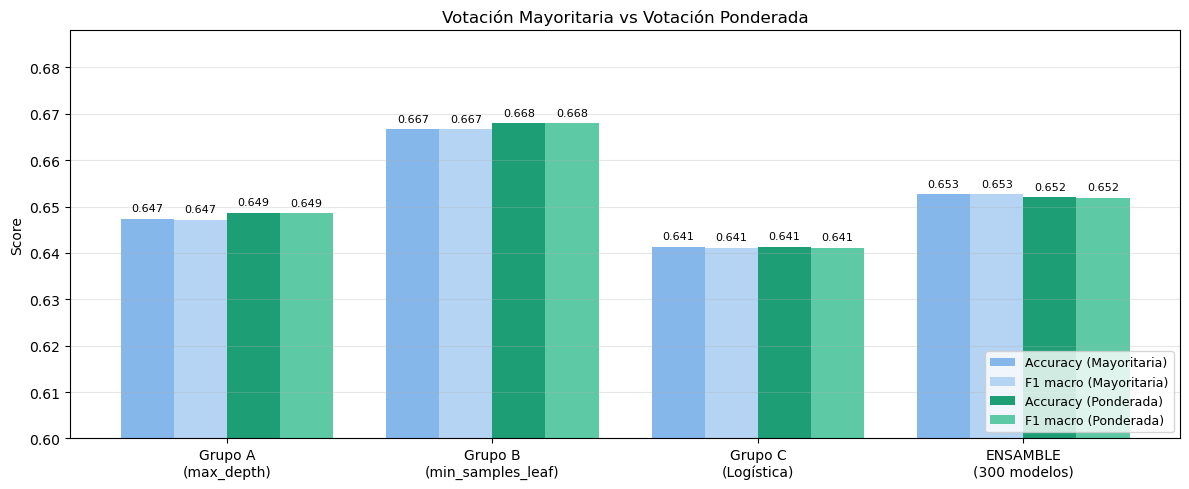

In [67]:
# Celda 9

resultados = {
    'Grupo A (max_depth=10)':        {'Acc_May': acc_A,   'F1_May': f1_A,   'Acc_Pond': acc_pA,   'F1_Pond': f1_pA},
    'Grupo B (min_samples_leaf=15)': {'Acc_May': acc_B,   'F1_May': f1_B,   'Acc_Pond': acc_pB,   'F1_Pond': f1_pB},
    'Grupo C (LogisticRegression)':  {'Acc_May': acc_C,   'F1_May': f1_C,   'Acc_Pond': acc_pC,   'F1_Pond': f1_pC},
    'ENSAMBLE (300 modelos)':        {'Acc_May': acc_ens, 'F1_May': f1_ens, 'Acc_Pond': acc_pond, 'F1_Pond': f1_pond},
}

#Tabla Comparativa
print("COMPARACIÓN: Votación Mayoritaria vs Votación Ponderada")
print("="*85)
print(f"{'Modelo':<35} {'--- Mayoritaria ---':>20} {'--- Ponderada ---':>20} {'Δ Acc':>8}")
print(f"{'':35} {'Acc':>10} {'F1':>10} {'Acc':>10} {'F1':>10} {'':>8}")
print("-"*85)

for nombre, metricas in resultados.items():
    delta = metricas['Acc_Pond'] - metricas['Acc_May']
    signo = "+" if delta >= 0 else ""
    print(f"{nombre:<35} {metricas['Acc_May']:>10.4f} {metricas['F1_May']:>10.4f} "
          f"{metricas['Acc_Pond']:>10.4f} {metricas['F1_Pond']:>10.4f} "
          f"{signo}{delta:>7.4f}")

print("-"*85)

#Gráfica comparativa
labels = ['Grupo A\n(max_depth)', 'Grupo B\n(min_samples_leaf)', 'Grupo C\n(Logística)', 'ENSAMBLE\n(300 modelos)']
x = np.arange(len(labels))
width = 0.2

acc_may = [acc_A, acc_B, acc_C, acc_ens]
f1_may  = [f1_A,  f1_B,  f1_C,  f1_ens]
acc_pon = [acc_pA, acc_pB, acc_pC, acc_pond]
f1_pon  = [f1_pA,  f1_pB,  f1_pC,  f1_pond]

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - 1.5*width, acc_may, width, label='Accuracy (Mayoritaria)',  color='#85B7EB')
bars2 = ax.bar(x - 0.5*width, f1_may,  width, label='F1 macro (Mayoritaria)', color='#B5D4F4')
bars3 = ax.bar(x + 0.5*width, acc_pon, width, label='Accuracy (Ponderada)',   color='#1D9E75')
bars4 = ax.bar(x + 1.5*width, f1_pon,  width, label='F1 macro (Ponderada)',  color='#5DCAA5')

# Valores sobre cada barra
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('Votación Mayoritaria vs Votación Ponderada')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0.60, max(max(acc_may), max(acc_pon), max(f1_may), max(f1_pon)) + 0.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Al comparar ambas metodologías, los resultados muestran diferencias mínimas pero reveladoras. La votación ponderada mejoró ligeramente el rendimiento individual del Grupo A y Grupo B (ambos con +0.0013 en Accuracy), pero no movió al Grupo C (Δ = 0.0000) y, paradójicamente, el ensamble completo de 300 modelos bajó levemente con la ponderación (de 0.6527 a 0.6520, Δ = −0.0007).

Esto se explica por la naturaleza de cada tipo de modelo. Los árboles de decisión (Grupos A y B) tienen variabilidad entre sí — cada bootstrap genera un árbol diferente con errores OOB distintos, por lo que la ponderación logra distinguir a los mejores y darles más peso. En cambio, las 100 regresiones logísticas del Grupo C producen modelos casi idénticos entre sí (el StandardScaler + LogisticRegression es determinista en su convergencia), así que sus errores OOB son homogéneos y los pesos alpha resultan prácticamente iguales, anulando el efecto de la ponderación.

El Grupo B (min_samples_leaf=15) es consistentemente el mejor modelo individual en ambas metodologías, alcanzando 0.6667 con votación mayoritaria y 0.6680 con ponderada, superando en ambos casos al ensamble completo de 300 modelos. Esto indica que la restricción de mínimo de observaciones por hoja es la forma de regularización más efectiva para este dataset, ya que obliga a cada hoja a representar al menos 15 observaciones, produciendo reglas más robustas y generalizables.

El ensamble de 300 modelos no superó al mejor grupo individual en ninguna de las dos metodologías. Esto ocurre porque el Grupo C (Accuracy 0.6413) tiene el rendimiento más bajo, y al aportar 100 de los 300 votos, "jala hacia abajo" el resultado del ensamble. En la votación mayoritaria, cada logística tiene el mismo voto que cada árbol del Grupo B, diluyendo la ventaja del grupo más fuerte. En la votación ponderada, aunque los pesos alpha intentan corregir esto, la diferencia de error OOB entre grupos no es lo suficientemente grande como para compensar el efecto de 100 modelos con rendimiento inferior.

En todos los modelos y ambas metodologías, se observa una convergencia casi perfecta entre Accuracy y F1-Score (diferencias ≤ 0.0002), lo cual confirma que los modelos clasifican ambas clases de forma equilibrada, sin sesgarse hacia "Exitoso" ni hacia "Novedad".

**Ventajas de la votación mayoritaria:** Es simple de implementar y de explicar. No requiere calcular errores OOB ni pesos. En este problema particular, produjo un ensamble ligeramente superior al ponderado (0.6527 vs 0.6520), demostrando que mayor complejidad no siempre equivale a mejor resultado.

**Desventajas de la votación mayoritaria:** Trata a todos los modelos como igualmente confiables. Un modelo con 51% de accuracy tiene el mismo voto que uno con 90%, lo cual puede ser subóptimo cuando hay diferencias significativas de calidad entre modelos.

**Ventajas de la votación ponderada:** Premia a los modelos más confiables y penaliza a los menos confiables, mejorando el rendimiento de los grupos individuales A y B (+0.0013 en ambos). Utiliza información gratuita (las observaciones OOB) que de otro modo se desperdiciaría. En escenarios donde la dispersión de errores entre modelos es mayor, su ventaja sería más pronunciada.

**Desventajas de la votación ponderada:** Requiere mayor complejidad computacional para calcular errores OOB y pesos alpha. En este caso, no mejoró el ensamble global, lo que sugiere que cuando los modelos tienen errores similares, la ponderación agrega complejidad sin beneficio claro. Además, es más difícil de explicar a audiencias no técnicas.

## Experimentos

Se experimentó debilitando el Grupo C (Regresión Logistica) quitándole el Pipeline, y se observó que incluso con un grupo notablemente inferior (caída de 3 puntos en Accuracy), la votación ponderada no mostró ventaja significativa sobre la mayoritaria, lo que confirma que la ponderación solo aporta valor cuando existen diferencias dramáticas de calidad entre modelos.

modelos[i] = LogisticRegression(max_iter=50, solver='lbfgs', random_state=seeds[i] #Muy pocas iteraciones 